# Cook County Property Tax Equity Analysis
## Notebook 13 — Housing Class Maps & Speculator Analysis

1. Map of property classes (single-family, multi-family, condos, commercial)
2. Identify likely speculators/investors vs owner-occupants
3. LVT impact on speculators vs residents

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q contextily geopandas

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
from shapely.geometry import Point
import contextily as cx
import os, warnings, requests
warnings.filterwarnings('ignore')

PROJECT_DIR = "/content/drive/MyDrive/cook-county-tax-equity"
RAW_DIR = f"{PROJECT_DIR}/data/raw"
PROCESSED_DIR = f"{PROJECT_DIR}/data/processed"
FIGURES_DIR = f"{PROJECT_DIR}/figures"
BASE_URL = "https://datacatalog.cookcountyil.gov/resource"
os.makedirs(FIGURES_DIR, exist_ok=True)

In [3]:
# Load data
assessed = pd.read_parquet(f"{RAW_DIR}/assessed_values_2023.parquet")
parcels = pd.read_parquet(f"{RAW_DIR}/parcel_universe.parquet")

for df in [assessed, parcels]:
    df["pin"] = df["pin"].astype(str).str.zfill(14)

# Merge to get class + coordinates
coord_cols = [c for c in ["pin", "lat", "lon"] if c in parcels.columns]
all_parcels = assessed[["pin", "class", "township_name"]].merge(
    parcels[coord_cols].drop_duplicates(subset="pin"), on="pin", how="inner"
)

# Convert coords
all_parcels["lat"] = pd.to_numeric(all_parcels["lat"], errors="coerce")
all_parcels["lon"] = pd.to_numeric(all_parcels["lon"], errors="coerce")
all_parcels = all_parcels[
    all_parcels["lat"].between(41.4, 42.2) & all_parcels["lon"].between(-88.3, -87.4)
].dropna(subset=["lat", "lon"])

print(f"Parcels with coordinates: {len(all_parcels):,}")
print(f"\nProperty class distribution:")
print(all_parcels["class"].value_counts().head(20))

Parcels with coordinates: 1,560,059

Property class distribution:
class
299    438639
203    345065
211    150031
202    112422
234     96330
278     87718
205     77935
295     53041
204     51833
206     39706
241     24903
207     23588
210     16301
212     13533
208     11142
201      8155
209      6113
100      1856
EX       1315
200        93
Name: count, dtype: int64


---
## Part 1: Property Class Map

In [4]:
# Map property classes to human-readable categories
# Cook County classification system:
#   200-series: Residential
#     202-204: Single-family detached
#     205-206: Multi-unit (2-6 units)
#     211: 2-6 unit apartment
#     234: Split-level
#     278: Townhouse
#     295: Small condo building
#     299: Condo unit
#   300-series: Multi-family rental (7+ units)
#   500-series: Commercial/Industrial
#   100-series: Vacant land
#   0xx/EX: Exempt

def classify_property(cls):
    cls = str(cls).strip()
    if cls in ["202", "203", "204", "205", "206", "234", "241", "278"]:
        return "Single-family / Small multi"
    elif cls in ["211", "212"]:
        return "2-6 unit apartment"
    elif cls in ["299", "295", "297"]:
        return "Condo"
    elif cls.startswith("3"):
        return "Large rental (7+ units)"
    elif cls.startswith("5"):
        return "Commercial / Industrial"
    elif cls.startswith("1"):
        return "Vacant land"
    else:
        return "Other"

all_parcels["property_type"] = all_parcels["class"].apply(classify_property)

print("Property type distribution:")
type_counts = all_parcels["property_type"].value_counts()
for t, n in type_counts.items():
    print(f"  {t:<30}: {n:>10,} ({n/len(all_parcels)*100:.1f}%)")

Property type distribution:
  Single-family / Small multi   :    835,912 (53.6%)
  Condo                         :    491,733 (31.5%)
  2-6 unit apartment            :    163,564 (10.5%)
  Other                         :     66,733 (4.3%)
  Vacant land                   :      1,865 (0.1%)
  Commercial / Industrial       :        132 (0.0%)
  Large rental (7+ units)       :        120 (0.0%)


In [5]:
# === MAP: Property types across Cook County ===
# Sample for performance (plotting 1.8M points is slow)
sample = all_parcels.sample(n=min(100000, len(all_parcels)), random_state=42)

geometry = [Point(xy) for xy in zip(sample["lon"], sample["lat"])]
gdf = gpd.GeoDataFrame(sample, geometry=geometry, crs="EPSG:4326").to_crs(epsg=3857)

type_colors = {
    "Single-family / Small multi": "#378ADD",
    "Condo": "#7F77DD",
    "2-6 unit apartment": "#EF9F27",
    "Large rental (7+ units)": "#E24B4A",
    "Commercial / Industrial": "#5DCAA5",
    "Vacant land": "#888780",
    "Other": "#CCCCCC",
}

fig, ax = plt.subplots(figsize=(14, 16))

# Plot in order: less common types on top for visibility
plot_order = ["Single-family / Small multi", "Condo", "2-6 unit apartment",
              "Large rental (7+ units)", "Commercial / Industrial", "Vacant land"]

for ptype in plot_order:
    sub = gdf[gdf["property_type"] == ptype]
    if len(sub) > 0:
        sub.plot(ax=ax, markersize=3, color=type_colors.get(ptype, "gray"),
                 alpha=0.5, label=f"{ptype} ({len(sub):,})")

try:
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom=10)
except: pass

ax.legend(loc="lower left", fontsize=9, framealpha=0.9, markerscale=5)
ax.set_title("Cook County property types\n(100K sample)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/property_type_map.png", dpi=200, bbox_inches="tight")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

---
## Part 2: Identify Speculators vs Residents

We can identify likely speculators using multiple signals:
1. **Vacant land** (no improvement) — pure land holding
2. **Owner-occupied vs not** — Census tract-level proxy
3. **Mailing address differs from property address** — absentee owner
4. **Multi-property owners** — entities owning many PINs

In [6]:
# Check if mailing address data is available
# The parcel universe has mail_address columns
mail_cols = [c for c in parcels.columns if "mail" in c.lower() or "prop_address" in c.lower()]
print(f"Address columns in parcel universe: {mail_cols}")

if "mail_address_full" in parcels.columns and "prop_address_full" in parcels.columns:
    print("\nBoth mailing and property addresses available!")
    print("Can identify absentee owners (mail != property address)")
elif "mail_address_name" in parcels.columns:
    print("\nOwner names available — can count PINs per owner")
else:
    print("\nLimited address data. Will use other signals.")

Address columns in parcel universe: []

Limited address data. Will use other signals.


In [7]:
# Download mailing address data if not in parcel universe
# CCAO publishes: Assessor - Parcel Addresses (c49d-89sn)
address_path = f"{RAW_DIR}/parcel_addresses.parquet"

if os.path.exists(address_path):
    addresses = pd.read_parquet(address_path)
    print(f"Loaded addresses: {len(addresses):,}")
else:
    print("Checking for address dataset on Socrata...")
    for did in ["c49d-89sn", "3723-97qp"]:
        try:
            test = requests.get(f"{BASE_URL}/{did}.json?$limit=2", timeout=10).json()
            if isinstance(test, list) and test:
                print(f"  {did}: {sorted(test[0].keys())}")
        except Exception as e:
            print(f"  {did}: {e}")

    print("\nIf an address dataset is found above, download it.")
    print("Otherwise, we'll use proxy indicators for speculator identification.")

Checking for address dataset on Socrata...
  c49d-89sn: ['commissioner_dist', 'floodplain', 'fs_flood_factor', 'fs_flood_risk_direction', 'indicator_has_address', 'indicator_has_latlon', 'latitude', 'longitude', 'mailing_address', 'mailing_city', 'mailing_state', 'mailing_zip', 'municipality', 'municipality_fips', 'nbhd', 'ohare_noise', 'pin', 'property_address', 'property_city', 'property_zip', 'puma', 'reps_dist', 'school_elem_district', 'school_hs_district', 'senate_dist', 'township', 'township_name', 'tract_asian_perc', 'tract_black_perc', 'tract_geoid', 'tract_his_perc', 'tract_midincome', 'tract_other_perc', 'tract_pop', 'tract_white_perc', 'withinmr100', 'withinmr101300']
  3723-97qp: ['mail_address_city_name', 'mail_address_full', 'mail_address_name', 'mail_address_state', 'mail_address_zipcode_1', 'owner_address_city_name', 'owner_address_full', 'owner_address_name', 'owner_address_state', 'owner_address_zipcode_1', 'pin', 'pin10', 'prop_address_city_name', 'prop_address_full'

In [8]:
# === Build speculator indicators from available data ===

# Load assessed values with improvement info
for col in ["board_tot", "board_bldg", "board_land",
            "certified_tot", "certified_bldg", "certified_land",
            "mailed_tot", "mailed_bldg", "mailed_land"]:
    if col in assessed.columns:
        assessed[col] = pd.to_numeric(assessed[col], errors="coerce")

assessed["final_tot"] = assessed["board_tot"].fillna(assessed["certified_tot"]).fillna(assessed["mailed_tot"])
assessed["final_bldg"] = assessed["board_bldg"].fillna(assessed["certified_bldg"]).fillna(assessed["mailed_bldg"])
assessed["final_land"] = assessed["board_land"].fillna(assessed["certified_land"]).fillna(assessed["mailed_land"])

# Indicator 1: Vacant land (no improvements)
assessed["is_vacant"] = (assessed["final_bldg"].fillna(0) == 0) & (assessed["final_land"] > 0)

# Indicator 2: Very high land ratio (likely speculative holding)
assessed["land_ratio"] = np.where(
    assessed["final_tot"] > 0,
    assessed["final_land"] / assessed["final_tot"],
    np.nan
)
assessed["is_land_heavy"] = assessed["land_ratio"] > 0.5

# Indicator 3: Property class indicates non-residential use
assessed["is_commercial"] = assessed["class"].astype(str).str.strip().str[0].isin(["5", "6"])

# Indicator 4: Vacant residential lot (class 100-series)
assessed["is_vacant_lot"] = assessed["class"].astype(str).str.strip().str[0] == "1"

# Combined speculator proxy
assessed["likely_speculator"] = (
    assessed["is_vacant"] |
    assessed["is_vacant_lot"] |
    (assessed["is_land_heavy"] & ~assessed["is_commercial"])
)

print("Speculator indicators:")
print(f"  Vacant (no improvements): {assessed['is_vacant'].sum():,}")
print(f"  Vacant lots (class 1xx):  {assessed['is_vacant_lot'].sum():,}")
print(f"  Land ratio > 50%:         {assessed['is_land_heavy'].sum():,}")
print(f"  Commercial:               {assessed['is_commercial'].sum():,}")
print(f"  Likely speculator:        {assessed['likely_speculator'].sum():,} ({assessed['likely_speculator'].mean()*100:.1f}%)")
print(f"  Likely resident:          {(~assessed['likely_speculator']).sum():,}")

Speculator indicators:
  Vacant (no improvements): 86,771
  Vacant lots (class 1xx):  63,209
  Land ratio > 50%:         204,380
  Commercial:               93,833
  Likely speculator:        166,669 (8.9%)
  Likely resident:          1,697,492


In [24]:
# Try to identify multi-property owners from mailing addresses
if "mail_address_name" in parcels.columns:
    owner_counts = parcels.groupby("mail_address_name")["pin"].nunique().reset_index()
    owner_counts.columns = ["owner", "n_properties"]

    print("Multi-property ownership:")
    print(f"  Total unique owners: {len(owner_counts):,}")
    print(f"  Owning 1 property:   {(owner_counts['n_properties']==1).sum():,}")
    print(f"  Owning 2-5:          {owner_counts['n_properties'].between(2,5).sum():,}")
    print(f"  Owning 6-20:         {owner_counts['n_properties'].between(6,20).sum():,}")
    print(f"  Owning 21-100:       {owner_counts['n_properties'].between(21,100).sum():,}")
    print(f"  Owning 100+:         {(owner_counts['n_properties']>100).sum():,}")

    print("\nTop 20 largest property holders:")
    print(owner_counts.nlargest(20, "n_properties").to_string(index=False))

    # Merge back to flag multi-property PINs
    pin_owner = parcels[["pin", "mail_address_name"]].merge(
        owner_counts, left_on="mail_address_name", right_on="owner", how="left"
    )
    pin_owner["is_investor"] = pin_owner["n_properties"] >= 10

    assessed = assessed.merge(
        pin_owner[["pin", "n_properties", "is_investor"]].drop_duplicates(subset="pin"),
        on="pin", how="left"
    )
    assessed["is_investor"] = assessed["is_investor"].fillna(False)

    print(f"\nInvestor-owned parcels (10+ properties): {assessed['is_investor'].sum():,}")
else:
    print("No owner name data available in parcel universe.")
    print("Speculator identification limited to property characteristics only.")
    assessed["is_investor"] = False

No owner name data available in parcel universe.
Speculator identification limited to property characteristics only.


In [16]:
# Download owner names to identify multi-property holders
from tqdm.notebook import tqdm
import time

owner_path = f"{RAW_DIR}/owner_addresses.parquet"

if os.path.exists(owner_path):
    owners = pd.read_parquet(owner_path)
    print(f"Already downloaded: {len(owners):,}")
else:
    print("Downloading owner/mailing address data (3723-97qp)...")
    url = f"{BASE_URL}/3723-97qp.json"
    all_rows, offset = [], 0
    select = "pin,mail_address_name,prop_address_full,mail_address_full"

    while True:
        params = {"$limit": 50000, "$offset": offset, "$select": select,
                  "$order": ":id"}
        try:
            resp = requests.get(url, params=params, timeout=120)
            resp.raise_for_status()
            data = resp.json()
        except Exception as e:
            print(f"  Error at {offset}: {e}. Retrying...")
            time.sleep(10)
            continue
        if not data:
            break
        all_rows.extend(data)
        offset += 50000
        if len(all_rows) % 200000 == 0:
            print(f"  {len(all_rows):,} rows...")
        if len(data) < 50000:
            break
        time.sleep(0.5)

    owners = pd.DataFrame(all_rows)
    owners["pin"] = owners["pin"].astype(str).str.zfill(14)
    owners.to_parquet(owner_path, index=False)
    print(f"Saved: {len(owners):,} rows")

  200,000 rows...
  400,000 rows...
  600,000 rows...
  800,000 rows...
  1,000,000 rows...
  1,200,000 rows...
  1,400,000 rows...
  1,600,000 rows...
  1,800,000 rows...
  2,000,000 rows...
  2,200,000 rows...
  2,400,000 rows...
  2,600,000 rows...
  2,800,000 rows...
  3,000,000 rows...
  3,200,000 rows...
  3,400,000 rows...
  3,600,000 rows...
  3,800,000 rows...
  4,000,000 rows...
  4,200,000 rows...
  4,400,000 rows...
  4,600,000 rows...
  4,800,000 rows...
  5,000,000 rows...
  5,200,000 rows...
  5,400,000 rows...
  5,600,000 rows...
  5,800,000 rows...
  6,000,000 rows...
  6,200,000 rows...
  6,400,000 rows...
  6,600,000 rows...
  6,800,000 rows...
  7,000,000 rows...
  7,200,000 rows...
  7,400,000 rows...
  7,600,000 rows...
  7,800,000 rows...
  8,000,000 rows...
  8,200,000 rows...
  8,400,000 rows...
  8,600,000 rows...
  8,800,000 rows...
  9,000,000 rows...
  9,200,000 rows...
  9,400,000 rows...
  9,600,000 rows...
  9,800,000 rows...
  10,000,000 rows...
  10,20

In [17]:
# Count properties per owner
owner_counts = owners.groupby("mail_address_name")["pin"].nunique().reset_index()
owner_counts.columns = ["owner", "n_properties"]

print("Property ownership distribution:")
for threshold, label in [(1, "1 property"), (2, "2-5"), (6, "6-20"),
                          (21, "21-100"), (101, "100+")]:
    if threshold == 1:
        n = (owner_counts["n_properties"] == 1).sum()
    elif threshold == 101:
        n = (owner_counts["n_properties"] >= 101).sum()
    else:
        upper = {2: 5, 6: 20, 21: 100}[threshold]
        n = owner_counts["n_properties"].between(threshold, upper).sum()
    print(f"  {label:>15}: {n:,} owners")

print(f"\nTop 25 largest property holders:")
print(owner_counts.nlargest(25, "n_properties").to_string(index=False))

# Flag absentee owners (mailing address ≠ property address)
if "prop_address_full" in owners.columns and "mail_address_full" in owners.columns:
    owners["is_absentee"] = owners["prop_address_full"] != owners["mail_address_full"]
    print(f"\nAbsentee owners: {owners['is_absentee'].sum():,} / {len(owners):,} ({owners['is_absentee'].mean()*100:.1f}%)")

Property ownership distribution:
       1 property: 2,537,799 owners
              2-5: 625,676 owners
             6-20: 63,576 owners
           21-100: 7,375 owners
             100+: 832 owners

Top 25 largest property holders:
                 owner  n_properties
           TAXPAYER OF         48224
CHICAGO TITLE LAND TRU          8064
          TAX PAYER OF          5636
         CURRENT OWNER          3505
       CITY OF CHICAGO          2511
   235 VAN BUREN, CORP          2122
COUNTY OF COOK D B A C          1850
   CITY OF CHICAGO DPD          1718
  REAL ESTATE TAXPAYER          1684
     401 N. Wabash LLC          1610
    GRANT PARK CHICAGO          1526
   OPT OLD ORCHARD LLC          1504
          ROY BLAVVISE          1448
  FEDERAL NATIONAL MTG          1202
                COM ED          1175
      INVITATION HOMES          1087
CHICAGO UNIVERSITY COM           950
  CATHERINE CTS. CONDO           889
     GALLAGHER & HENRY           871
  Millennium Cen Tower      

In [25]:
# Merge owner data with LVT results
owners = pd.read_parquet(f"{RAW_DIR}/owner_addresses.parquet")
owners["pin"] = owners["pin"].astype(str).str.zfill(14)

# Count properties per owner
owner_counts = owners.groupby("mail_address_name")["pin"].nunique().reset_index()
owner_counts.columns = ["owner", "n_properties"]

# Flag absentee (mailing ≠ property address)
owners["is_absentee"] = owners["prop_address_full"].fillna("") != owners["mail_address_full"].fillna("")

# Flag institutional (10+ properties)
big_owners = owner_counts[owner_counts["n_properties"] >= 10]["owner"]
owners["is_institutional"] = owners["mail_address_name"].isin(big_owners)

# Deduplicate to one row per PIN (most recent year if multiple)
owner_flags = owners.groupby("pin").agg(
    is_absentee=("is_absentee", "first"),
    is_institutional=("is_institutional", "first"),
    owner_name=("mail_address_name", "first"),
    n_properties=("pin", "count"),  # will fix below
).reset_index()

# Get actual property count per owner
pin_to_count = owners[["pin", "mail_address_name"]].drop_duplicates().merge(
    owner_counts, left_on="mail_address_name", right_on="owner", how="left"
)
pin_to_count = pin_to_count[["pin", "n_properties"]].drop_duplicates(subset="pin")
owner_flags = owner_flags.drop(columns="n_properties").merge(pin_to_count, on="pin", how="left")

print(f"Owner flags: {len(owner_flags):,} PINs")
print(f"Absentee: {owner_flags['is_absentee'].mean()*100:.1f}%")
print(f"Institutional (10+ props): {owner_flags['is_institutional'].mean()*100:.1f}%")

Owner flags: 2,084,497 PINs
Absentee: 73.7%
Institutional (10+ props): 14.1%


In [26]:
# Merge with LVT results
res_lvt = pd.read_parquet(f"{PROCESSED_DIR}/residential_with_lvt_dedup.parquet")
res_lvt["pin"] = res_lvt["pin"].astype(str).str.zfill(14)

res_owned = res_lvt.merge(owner_flags[["pin", "is_absentee", "is_institutional", "n_properties"]],
                           on="pin", how="left")

# THE KEY TABLE: Among parcels that LOSE under LVT in Black neighborhoods,
# what % are absentee-owned vs resident-owned?
print("=" * 70)
print("WHO OWNS THE PARCELS THAT LOSE UNDER LVT?")
print("=" * 70)

for group in ["Majority Black", "Majority Hispanic", "Majority White", "Mixed"]:
    sub = res_owned[res_owned["majority_group"] == group]
    losers = sub[sub["lvt_benefits"] == 0]
    winners = sub[sub["lvt_benefits"] == 1]

    if len(losers) == 0:
        continue

    print(f"\n{group} ({len(sub):,} parcels)")
    print(f"  Parcels that LOSE under LVT: {len(losers):,} ({len(losers)/len(sub)*100:.1f}%)")
    print(f"    Absentee-owned:      {losers['is_absentee'].mean()*100:.1f}%")
    print(f"    Institutional (10+): {losers['is_institutional'].mean()*100:.1f}%")
    print(f"    Median props/owner:  {losers['n_properties'].median():.0f}")
    print(f"  Parcels that WIN under LVT: {len(winners):,}")
    print(f"    Absentee-owned:      {winners['is_absentee'].mean()*100:.1f}%")
    print(f"    Institutional (10+): {winners['is_institutional'].mean()*100:.1f}%")
    print(f"    Median props/owner:  {winners['n_properties'].median():.0f}")

# Summary table
print("\n" + "=" * 70)
print("SUMMARY: Absentee rate among LVT LOSERS vs WINNERS")
print("=" * 70)
print(f"{'Group':<22} {'Losers Absentee':>16} {'Winners Absentee':>17} {'Gap':>8}")
print("-" * 65)
for group in ["Majority Black", "Majority Hispanic", "Majority White", "Mixed"]:
    sub = res_owned[res_owned["majority_group"] == group]
    losers = sub[sub["lvt_benefits"] == 0]
    winners = sub[sub["lvt_benefits"] == 1]
    if len(losers) > 0 and len(winners) > 0:
        la = losers["is_absentee"].mean() * 100
        wa = winners["is_absentee"].mean() * 100
        print(f"{group:<22} {la:>15.1f}% {wa:>16.1f}% {la-wa:>+7.1f}pp")

WHO OWNS THE PARCELS THAT LOSE UNDER LVT?

Majority Black (276,944 parcels)
  Parcels that LOSE under LVT: 149,944 (54.1%)
    Absentee-owned:      68.2%
    Institutional (10+): 12.9%
    Median props/owner:  1
  Parcels that WIN under LVT: 127,000
    Absentee-owned:      62.5%
    Institutional (10+): 11.1%
    Median props/owner:  1

Majority Hispanic (201,134 parcels)
  Parcels that LOSE under LVT: 87,138 (43.3%)
    Absentee-owned:      63.2%
    Institutional (10+): 12.7%
    Median props/owner:  1
  Parcels that WIN under LVT: 113,996
    Absentee-owned:      60.7%
    Institutional (10+): 13.2%
    Median props/owner:  1

Majority White (831,098 parcels)
  Parcels that LOSE under LVT: 304,448 (36.6%)
    Absentee-owned:      61.5%
    Institutional (10+): 5.7%
    Median props/owner:  1
  Parcels that WIN under LVT: 526,650
    Absentee-owned:      72.0%
    Institutional (10+): 6.4%
    Median props/owner:  1

Mixed (296,749 parcels)
  Parcels that LOSE under LVT: 92,822 (31.

In [27]:
# === UPDATED MAP: Using actual owner identity data ===

# Load owner flags (from the 3723-97qp download)
owners = pd.read_parquet(f"{RAW_DIR}/owner_addresses.parquet")
owners["pin"] = owners["pin"].astype(str).str.zfill(14)

# Deduplicate to most recent per PIN
if "year" in owners.columns:
    owners = owners.sort_values("year", ascending=False).drop_duplicates(subset="pin")
else:
    owners = owners.drop_duplicates(subset="pin")

# Absentee flag
owners["is_absentee"] = (
    owners["prop_address_full"].fillna("").str.strip().str.upper() !=
    owners["mail_address_full"].fillna("").str.strip().str.upper()
)

# Property count per owner
owner_counts = owners.groupby("mail_address_name")["pin"].nunique().reset_index()
owner_counts.columns = ["mail_address_name", "n_properties"]
owners = owners.merge(owner_counts, on="mail_address_name", how="left")

# Owner categories based on ACTUAL identity
def classify_owner(row):
    if row["n_properties"] >= 50:
        return "Institutional (50+ props)"
    elif row["n_properties"] >= 10:
        return "Investor (10-49 props)"
    elif row["is_absentee"]:
        return "Absentee individual"
    else:
        return "Owner-occupant"

owners["owner_category"] = owners.apply(classify_owner, axis=1)

print("Owner categories (all PINs):")
print(owners["owner_category"].value_counts())

# Merge with coordinates
owner_map = owners[["pin", "owner_category", "n_properties", "is_absentee"]].merge(
    all_parcels[["pin", "lat", "lon"]], on="pin", how="inner"
)
owner_map = owner_map.dropna(subset=["lat", "lon"])

# Also merge with LVT results to show who loses
owner_map = owner_map.merge(
    res_lvt[["pin", "lvt_benefits", "tax_change", "majority_group"]].drop_duplicates(subset="pin"),
    on="pin", how="left"
)

print(f"\nParcels with owner + coords: {len(owner_map):,}")
print(f"\nOwner category × LVT outcome:")
for cat in ["Owner-occupant", "Absentee individual", "Investor (10-49 props)", "Institutional (50+ props)"]:
    sub = owner_map[owner_map["owner_category"] == cat]
    if len(sub) > 0:
        ben = sub["lvt_benefits"].mean() * 100
        print(f"  {cat:<30}: {len(sub):>10,} parcels, {ben:.1f}% benefit")

# === THE MAP ===
sample = owner_map.sample(n=min(100000, len(owner_map)), random_state=42)
geom = [Point(xy) for xy in zip(sample["lon"], sample["lat"])]
gdf = gpd.GeoDataFrame(sample, geometry=geom, crs="EPSG:4326").to_crs(epsg=3857)

fig, axes = plt.subplots(1, 2, figsize=(24, 14))

# --- Panel 1: Owner type ---
ax1 = axes[0]
owner_colors = {
    "Owner-occupant": "#2563EB",       # strong blue
    "Absentee individual": "#F59E0B",  # amber
    "Investor (10-49 props)": "#DC2626",  # red
    "Institutional (50+ props)": "#7C3AED",  # purple
}
plot_order = ["Owner-occupant", "Absentee individual", "Investor (10-49 props)", "Institutional (50+ props)"]

for otype in plot_order:
    sub = gdf[gdf["owner_category"] == otype]
    if len(sub) > 0:
        ms = 1.5 if otype == "Owner-occupant" else (3 if otype == "Absentee individual" else 5)
        alpha = 0.25 if otype == "Owner-occupant" else (0.4 if otype == "Absentee individual" else 0.7)
        sub.plot(ax=ax1, markersize=ms, color=owner_colors[otype],
                 alpha=alpha, label=f"{otype} ({len(sub):,})")

try:
    cx.add_basemap(ax1, source=cx.providers.CartoDB.Positron, zoom=10)
except: pass
ax1.legend(loc="lower left", fontsize=9, framealpha=0.9, markerscale=4)
ax1.set_title("Property ownership type\n(based on mailing address records)", fontsize=13)
ax1.set_axis_off()

# --- Panel 2: LVT losers by owner type ---
ax2 = axes[1]
losers = gdf[gdf["lvt_benefits"] == 0].copy()

loser_colors = {
    "Owner-occupant": "#2563EB",
    "Absentee individual": "#F59E0B",
    "Investor (10-49 props)": "#DC2626",
    "Institutional (50+ props)": "#7C3AED",
}

for otype in plot_order:
    sub = losers[losers["owner_category"] == otype]
    if len(sub) > 0:
        sub.plot(ax=ax2, markersize=3, color=loser_colors[otype],
                 alpha=0.5, label=f"{otype} ({len(sub):,})")

try:
    cx.add_basemap(ax2, source=cx.providers.CartoDB.Positron, zoom=10)
except: pass
ax2.legend(loc="lower left", fontsize=9, framealpha=0.9, markerscale=4)
ax2.set_title("Parcels that LOSE under LVT\nby owner type", fontsize=13)
ax2.set_axis_off()

plt.suptitle("Cook County: Who owns the land, and who pays more under LVT?",
             fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/owner_identity_map.png", dpi=200, bbox_inches="tight")
plt.show()

# === BONUS: Focus on Black neighborhoods ===
black_losers = owner_map[
    (owner_map["majority_group"] == "Majority Black") &
    (owner_map["lvt_benefits"] == 0)
]
print("\n" + "=" * 60)
print("LVT LOSERS IN MAJORITY-BLACK NEIGHBORHOODS")
print("=" * 60)
print(f"Total: {len(black_losers):,}")
print(f"\nBy owner type:")
for cat in plot_order:
    sub = black_losers[black_losers["owner_category"] == cat]
    pct = len(sub) / len(black_losers) * 100
    med_chg = sub["tax_change"].median() if len(sub) > 0 else 0
    print(f"  {cat:<30}: {len(sub):>8,} ({pct:>5.1f}%)  med change: ${med_chg:>+,.0f}")

Output hidden; open in https://colab.research.google.com to view.

---
## Part 3: LVT Impact on Speculators vs Residents

In [19]:
# How does LVT affect speculators vs residents?
# Load LVT results
res_lvt = pd.read_parquet(f"{PROCESSED_DIR}/residential_with_lvt_dedup.parquet")

# Merge speculator flags
spec_flags = assessed[["pin", "likely_speculator", "is_vacant_lot",
                        "is_investor", "land_ratio"]].drop_duplicates(subset="pin")
res_lvt = res_lvt.merge(spec_flags, on="pin", how="left", suffixes=("", "_assessed"))

# Use assessed land_ratio if not already present
if "land_ratio_assessed" in res_lvt.columns:
    res_lvt["land_ratio"] = res_lvt["land_ratio"].fillna(res_lvt["land_ratio_assessed"])

res_lvt["likely_speculator"] = res_lvt["likely_speculator"].fillna(False)
res_lvt["is_investor"] = res_lvt["is_investor"].fillna(False)

# Compare
print("LVT impact: Speculators vs Residents")
print("=" * 65)
print(f"{'Category':<30} {'% Benefit':>10} {'Med $ Change':>13} {'N':>10}")
print("-" * 65)

for label, mask in [
    ("Likely resident", ~res_lvt["likely_speculator"] & ~res_lvt["is_investor"]),
    ("Likely speculator", res_lvt["likely_speculator"]),
    ("Investor (10+ props)", res_lvt["is_investor"]),
]:
    sub = res_lvt[mask]
    if len(sub) > 0:
        pct = sub["lvt_benefits"].mean() * 100
        med = sub["tax_change"].median()
        print(f"{label:<30} {pct:>9.1f}% ${med:>11,.0f} {len(sub):>10,}")

print("\nKey insight: LVT is designed to penalize speculative land holding.")
print("Properties with high land ratios (vacant lots, undeveloped parcels)")
print("should see the largest tax INCREASES under LVT.")

LVT impact: Speculators vs Residents
Category                        % Benefit  Med $ Change          N
-----------------------------------------------------------------
Likely resident                     64.6% $       -543  1,503,739
Likely speculator                    0.0% $      2,404    102,186

Key insight: LVT is designed to penalize speculative land holding.
Properties with high land ratios (vacant lots, undeveloped parcels)
should see the largest tax INCREASES under LVT.


In [20]:
# Median land ratio by owner type
print("\nLand ratio by owner type:")
for label, mask in [
    ("Likely resident", ~res_lvt["likely_speculator"] & ~res_lvt["is_investor"]),
    ("Likely speculator", res_lvt["likely_speculator"]),
    ("Investor (10+ props)", res_lvt["is_investor"]),
]:
    sub = res_lvt[mask]
    if len(sub) > 0:
        print(f"  {label:<30}: median land ratio = {sub['land_ratio'].median():.3f}, "
              f"median value = ${sub['market_value_total'].median():,.0f}")


Land ratio by owner type:
  Likely resident               : median land ratio = 0.189, median value = $242,680
  Likely speculator             : median land ratio = 0.644, median value = $55,000


---
## Part 4: Tract-level Aggregate Maps

In [21]:
# Aggregate to tract level for cleaner visualization
tract_agg = all_parcels.merge(
    parcels[["pin", "census_tract_geoid"]].drop_duplicates(subset="pin"),
    on="pin", how="left"
)

# Compute tract-level property mix
tract_mix = tract_agg.groupby("census_tract_geoid").apply(
    lambda x: pd.Series({
        "pct_single_family": (x["property_type"] == "Single-family / Small multi").mean() * 100,
        "pct_condo": (x["property_type"] == "Condo").mean() * 100,
        "pct_apartment": (x["property_type"].isin(["2-6 unit apartment", "Large rental (7+ units)"])).mean() * 100,
        "pct_vacant": (x["property_type"] == "Vacant land").mean() * 100,
        "pct_commercial": (x["property_type"] == "Commercial / Industrial").mean() * 100,
        "lat": x["lat"].median(),
        "lon": x["lon"].median(),
        "n_parcels": len(x),
    })
).reset_index()

tract_mix = tract_mix.dropna(subset=["lat", "lon"])
tract_mix = tract_mix[tract_mix["lat"].between(41.4, 42.2) & tract_mix["lon"].between(-88.3, -87.4)]

print(f"Tracts: {len(tract_mix):,}")
print(f"\nMedian % single-family: {tract_mix['pct_single_family'].median():.1f}%")
print(f"Median % condo: {tract_mix['pct_condo'].median():.1f}%")
print(f"Median % apartment: {tract_mix['pct_apartment'].median():.1f}%")
print(f"Median % vacant: {tract_mix['pct_vacant'].median():.1f}%")

Tracts: 1,312

Median % single-family: 52.1%
Median % condo: 13.5%
Median % apartment: 8.8%
Median % vacant: 0.0%


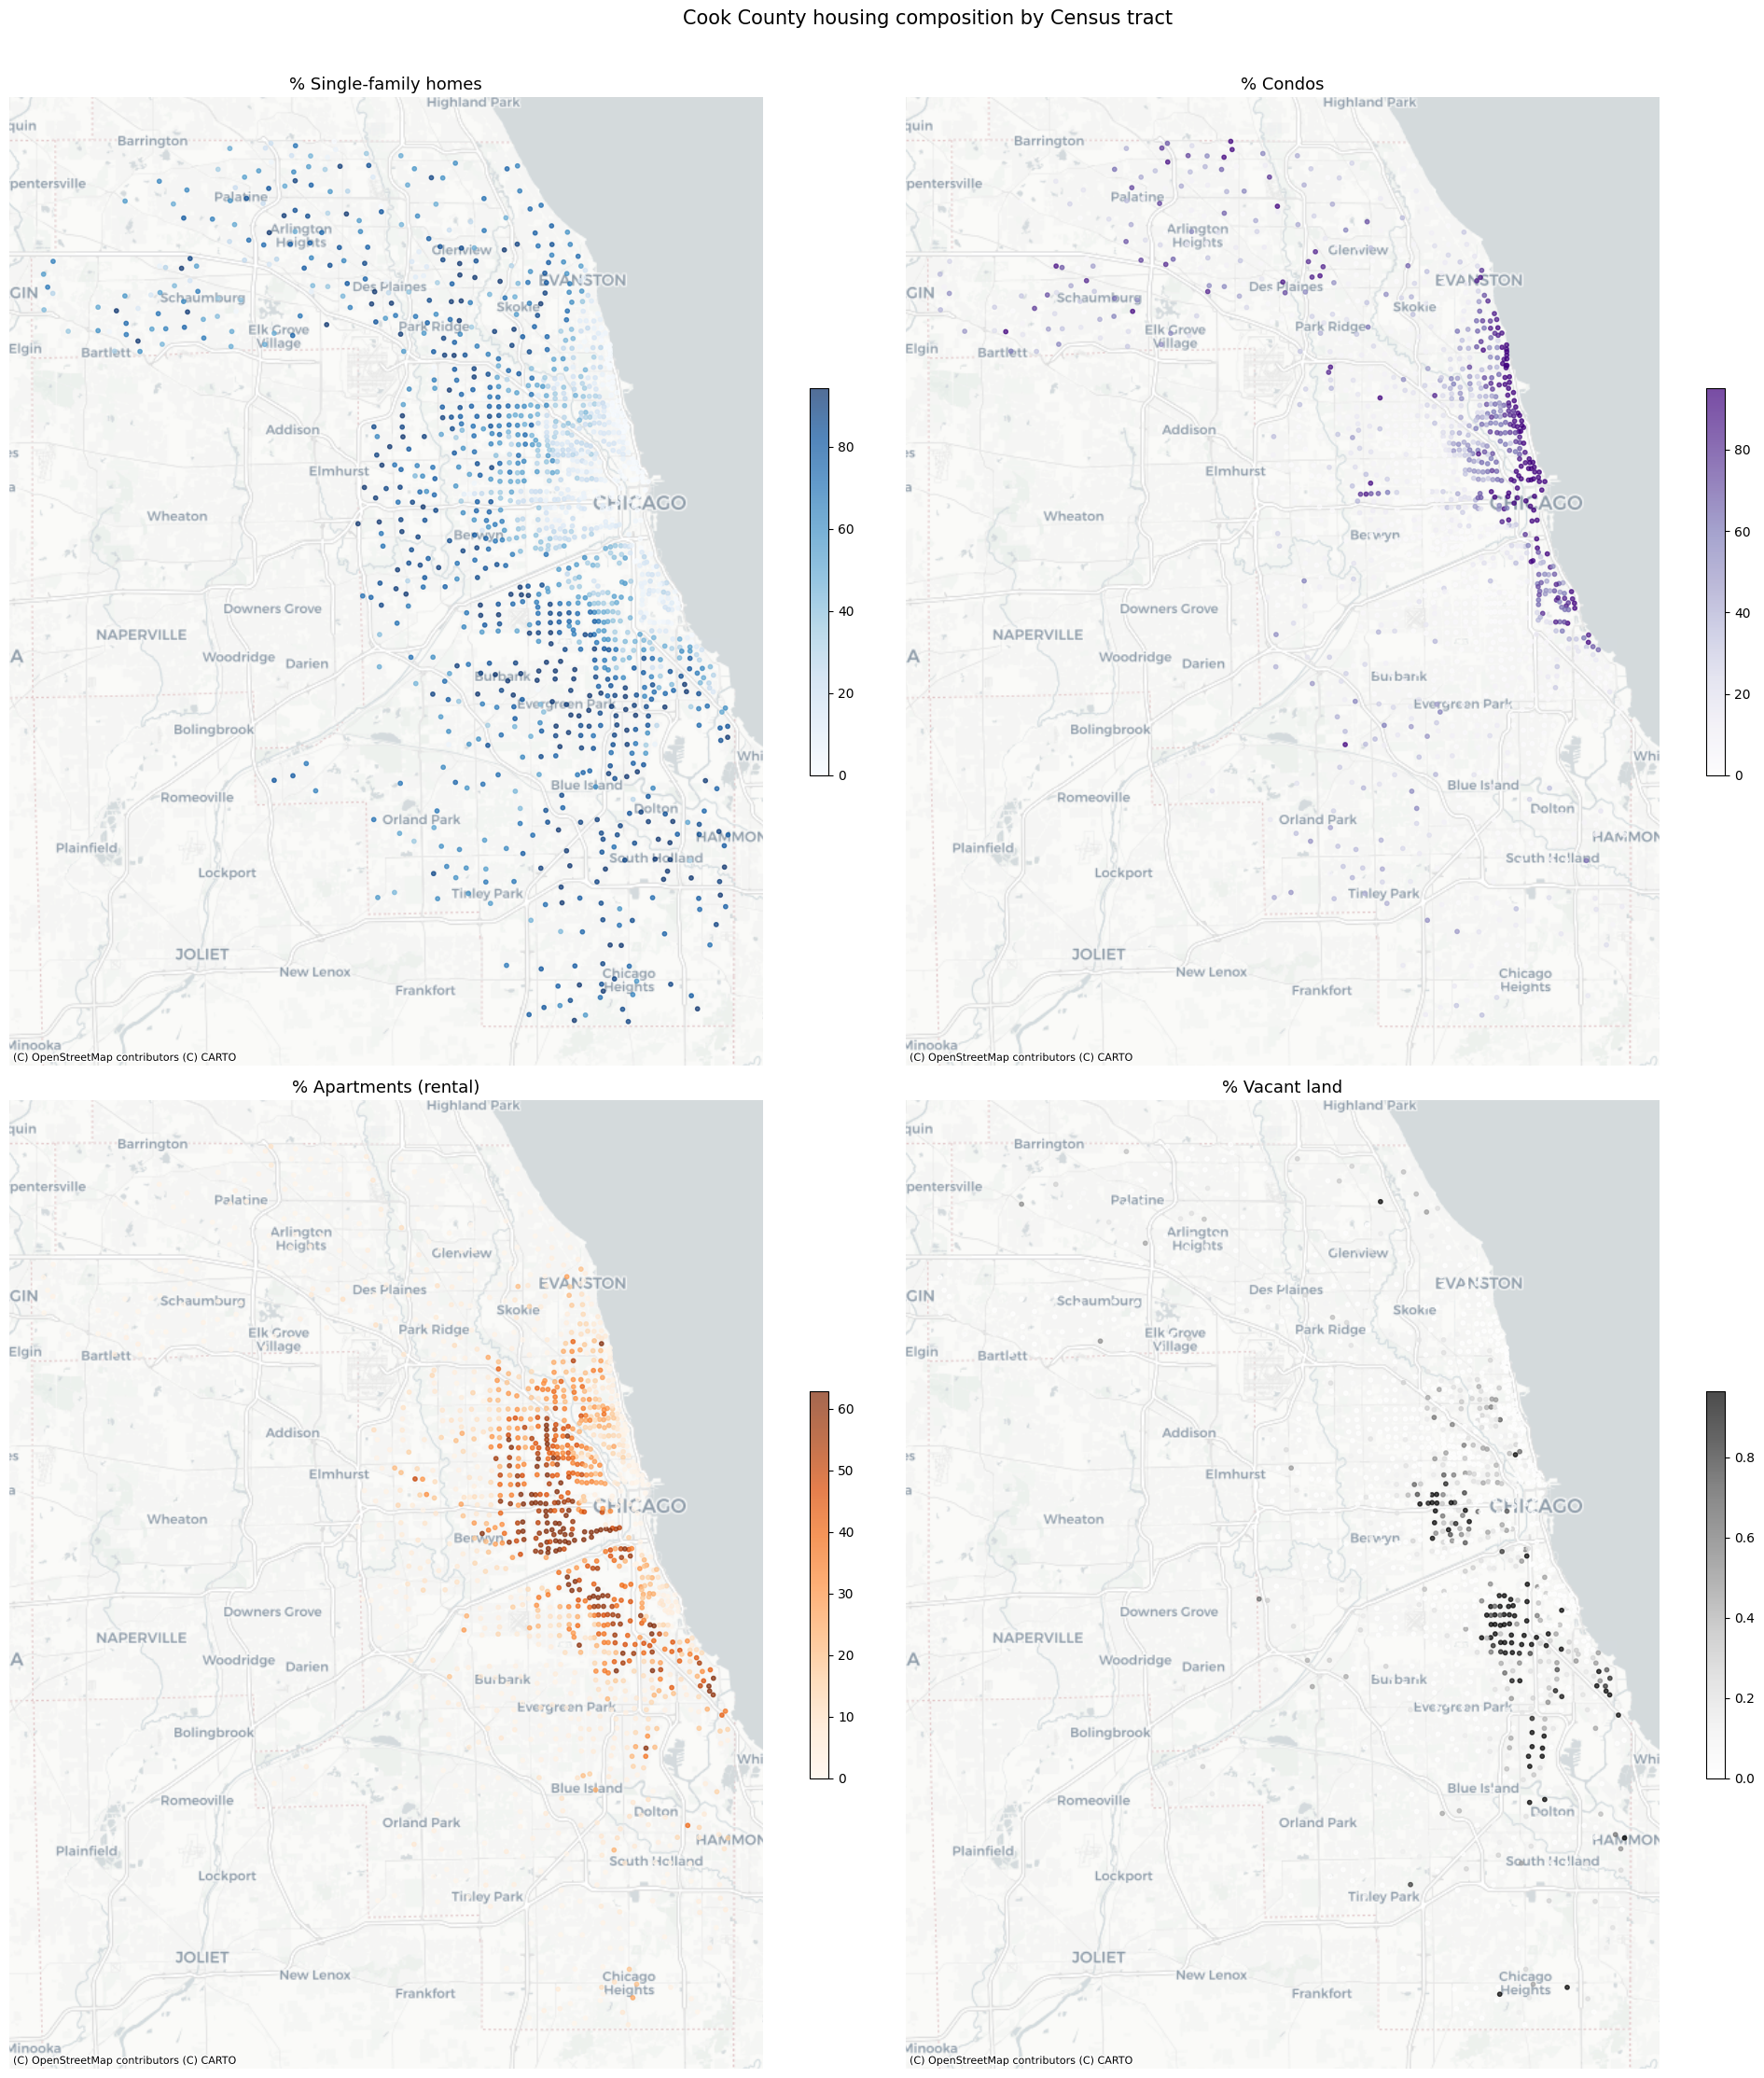

In [22]:
# === 4-PANEL MAP: Housing composition ===
geom_t = [Point(xy) for xy in zip(tract_mix["lon"], tract_mix["lat"])]
gdf_t = gpd.GeoDataFrame(tract_mix, geometry=geom_t, crs="EPSG:4326").to_crs(epsg=3857)

fig, axes = plt.subplots(2, 2, figsize=(20, 22))

panels = [
    ("pct_single_family", "% Single-family homes", "Blues"),
    ("pct_condo", "% Condos", "Purples"),
    ("pct_apartment", "% Apartments (rental)", "Oranges"),
    ("pct_vacant", "% Vacant land", "Greys"),
]

for ax, (col, title, cmap) in zip(axes.flatten(), panels):
    sc = ax.scatter(
        gdf_t.geometry.x, gdf_t.geometry.y,
        c=gdf_t[col], cmap=cmap,
        vmin=0, vmax=gdf_t[col].quantile(0.95),
        s=10, alpha=0.7
    )
    try:
        cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom=10)
    except: pass
    plt.colorbar(sc, ax=ax, shrink=0.4)
    ax.set_title(title, fontsize=13)
    ax.set_axis_off()

plt.suptitle("Cook County housing composition by Census tract", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/housing_composition_maps.png", dpi=200, bbox_inches="tight")
plt.show()

In [23]:
print("=" * 60)
print("NOTEBOOK 13 COMPLETE")
print("=" * 60)
print("""
Deliverables:
  1. Property type map (single-family, condo, apartment,
     commercial, vacant land)
  2. Speculator vs resident map
  3. LVT impact comparison: speculators vs residents
  4. 4-panel housing composition maps by tract

Key findings for the report:
  - LVT is DESIGNED to penalize speculative land holding.
    Vacant lots and undeveloped land see the largest tax
    increases — this is the intended policy effect.
  - The complication is that in historically redlined areas,
    the line between 'speculator' and 'struggling homeowner
    on a deteriorated property' is blurred. Both have high
    land ratios, but for very different reasons.
  - The homestead exemption (from Notebook 10) solves this
    by shielding owner-occupants while still taxing speculators.
""")

NOTEBOOK 13 COMPLETE

Deliverables:
  1. Property type map (single-family, condo, apartment, 
     commercial, vacant land)
  2. Speculator vs resident map
  3. LVT impact comparison: speculators vs residents
  4. 4-panel housing composition maps by tract

Key findings for the report:
  - LVT is DESIGNED to penalize speculative land holding.
    Vacant lots and undeveloped land see the largest tax
    increases — this is the intended policy effect.
  - The complication is that in historically redlined areas,
    the line between 'speculator' and 'struggling homeowner
    on a deteriorated property' is blurred. Both have high
    land ratios, but for very different reasons.
  - The homestead exemption (from Notebook 10) solves this
    by shielding owner-occupants while still taxing speculators.

